Reading in basemap...
Reading in GeoDataFrame...
Reading in CAMELS shapefile...
Reading in GEFS xarray dataset...
Converting air temperature to DataFrame...
Merging GeoDataFrame with temperature data...


/home/m10925360/.local/lib/python3.11/site-packages/geopandas/plotting.py:732: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(values.dtype):


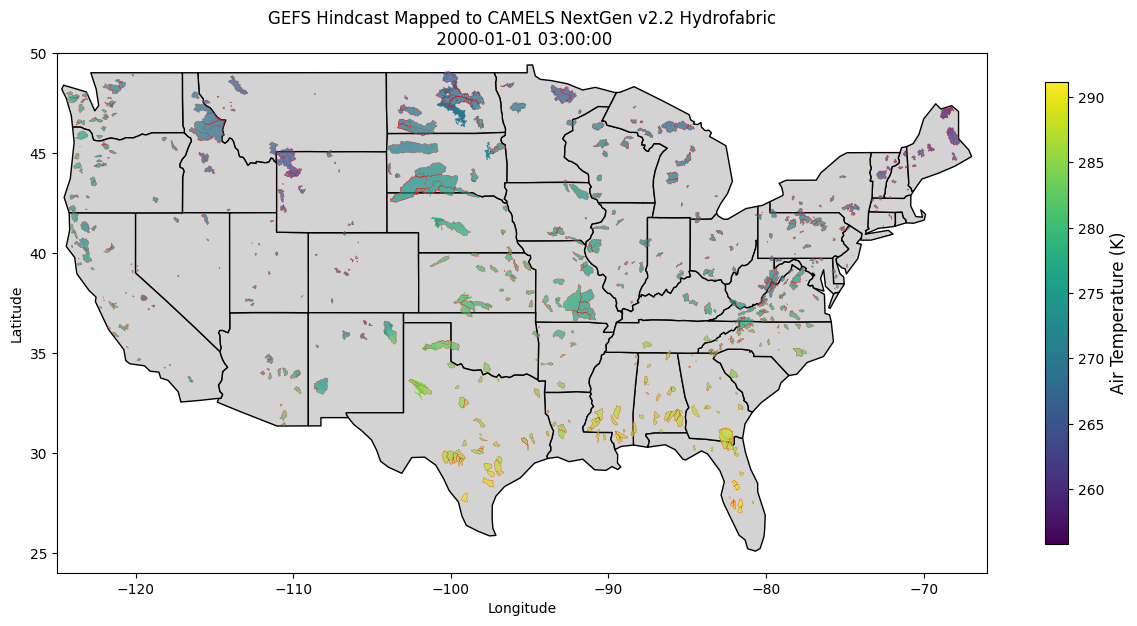

In [1]:
import geopandas as gpd
import xarray as xr
import numpy as np
import glob
import os
import re
import contextily as cx
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show as rioshow
import pandas as pd
%matplotlib inline

# Paths for the data files
basemap_path = '/beegfs/projects/aw-ciroh/common/gis/basemaps/ne_110m_admin_1_states_provinces.shp'
gdf_path = '/beegfs/projects/aw-ciroh/common/gis/hydrofabrics/conus/ngen.v2_2.camels.divides.gpkg'
forc_path = '/beegfs/projects/aw-ciroh/common/met_fcsts/gefs_v12/camels_ngen_hf_v2.2/2000/gefs_v12_hcst.2000010100.camels_ngen_hf_v2_2.ens01.nc'
camels_shp_path = '/beegfs/projects/aw-ciroh/common/gis/camels_revised_awood/gagesII_671_shp_albers.clean.gpkg'

# Read the basemap and reproject to EPSG:4326
print('Reading in basemap...')
basemap = gpd.read_file(basemap_path)
basemap = basemap.to_crs(epsg=4326)

# Read the GeoPackage file into a GeoDataFrame and reproject to EPSG:4326
print('Reading in GeoDataFrame...')
gdf = gpd.read_file(gdf_path)
gdf['num_id'] = gdf['divide_id'].str.extract(r'(\d+)', expand=False)  # Extract and convert to numeric
gdf = gdf.dropna(subset=['num_id'])  # Drop rows where num_id is NaN
gdf['num_id'] = gdf['num_id'].astype(int)  # Convert to integer type for matching
gdf = gdf.to_crs(epsg=4326)

# Read the CAMELS shapefile and reproject to EPSG:4326
print('Reading in CAMELS shapefile...')
camels = gpd.read_file(camels_shp_path)
camels = camels.to_crs(epsg=4326)

# Read the NetCDF file into an xarray Dataset
print('Reading in GEFS xarray dataset...')
ds = xr.open_dataset(forc_path)

# Extract the 'airtemp' variable at a specific time step (e.g., the first time step) and convert to a DataFrame
print('Converting air temperature to DataFrame...')
airtemp_df = ds['TMP_2maboveground'].isel(time=0).to_dataframe()

# Ensure 'hru' in airtemp_df is numeric
airtemp_df.index = airtemp_df.index.str.extract(r'(\d+)', expand=False)  # Extract numeric part from index
airtemp_df = airtemp_df.dropna()  # Drop NaNs
airtemp_df.index = airtemp_df.index.astype('float')  # Convert index to integer for matching

# Join the GeoDataFrame with the air temperature data on the numeric 'num_id' and 'hru'
print('Merging GeoDataFrame with temperature data...')
gdf_merged = gdf.merge(airtemp_df, left_on='num_id', right_index=True)

# Plot the GeoDataFrame, colored by 'airtemp', with the basemap and CAMELS outlines
fig, ax = plt.subplots(figsize=(15, 10))
basemap.plot(ax=ax, color='lightgrey', edgecolor='black')  # Plot the basemap
plot = gdf_merged.plot(column='TMP_2maboveground', cmap='viridis', legend=True, ax=ax, legend_kwds={'shrink': 0.6})  # Plot the HRU data
camels.plot(ax=ax, color='none', edgecolor='red', linewidth=0.1)  # Plot the CAMELS shapes with red outlines

# Set the extent for CONUS (approximate boundaries)
ax.set_xlim([-125, -66])  # Longitude range for CONUS
ax.set_ylim([24, 50])     # Latitude range for CONUS

# Customize the colorbar with a label
cbar = plot.get_figure().get_axes()[1]  # Get the colorbar axis (usually the second axis)
cbar.set_ylabel('Air Temperature (K)', fontsize=12)

# Customize plot
plt.title('GEFS Hindcast Mapped to CAMELS NextGen v2.2 Hydrofabric\n ' + str(airtemp_df.time.iloc[0]))
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


# plot one basin

In [2]:
# time slice to plot
time_idx = 0

# Paths for the data files
hf_path = '/beegfs/projects/aw-ciroh/common/gis/hydrofabrics/conus/ngen.v2_2.camels.gpkg'
camels_shp_path = '/beegfs/projects/aw-ciroh/common/gis/camels_revised_awood/gagesII_671_shp_albers.clean.gpkg'
forc_path = '/beegfs/projects/aw-ciroh/common/met_fcsts/gefs_v12/camels_ngen_hf_v2.2/2000/gefs_v12_hcst.2000010100.camels_ngen_hf_v2_2.ens01.nc'
rfc_basin_path = '/beegfs/projects/aw-ciroh/common/gis/shapes/rfc_basins/camels_rfc/camels_rfc_basins.gpkg'
rfc_fcst_points_path = "/beegfs/projects/aw-ciroh/common/gis/shapes/rfc_basins/camels_rfc/camels_rfc_basins.csv"

# Read the CSV file
df_rfc = pd.read_csv(rfc_fcst_points_path)
rfc_fcst_points = gpd.GeoDataFrame(
    df_rfc,
    geometry=gpd.points_from_xy(df_rfc['Lon'], df_rfc['Lat']),  # Replace with actual column names for Lon/Lat
    crs="EPSG:4326"  # Assuming the coordinates are in WGS84
)

# Read the GeoPackage file and CAMELS shapefile
print('Reading in divides, flowpaths, and nexus...')
divides = gpd.read_file(hf_path, layer='divides').to_crs(epsg=4326)
divides['num_id'] = divides['divide_id'].str.extract(r'(\d+)', expand=False)  # Extract numeric part
divides = divides.dropna(subset=['num_id']).copy()  # Drop rows where num_id is NaN
divides['num_id'] = divides['num_id'].astype(int)  # Convert to integer type

# read in flowpaths and nexus
flowpaths = gpd.read_file(hf_path, layer='flowpaths').to_crs(epsg=4326)
nexus = gpd.read_file(hf_path, layer='nexus').to_crs(epsg=4326)
#rfc_basins = gpd.read_file(rfc_path).to_crs(epsg=4326)

print('Reading in CAMELS shapefile...')
camels = gpd.read_file(camels_shp_path).to_crs(epsg=4326)

# Read the NetCDF file into an xarray Dataset
print('Reading in GEFS xarray dataset...')
ds = xr.open_dataset(forc_path)

# Extract the 'airtemp' variable at a specific time step (e.g., the first time step)
print('Converting air temperature to DataFrame...')
airtemp_df = ds['TMP_2maboveground'].isel(time=time_idx).to_dataframe()
airtemp_df.TMP_2maboveground = airtemp_df.TMP_2maboveground-273.15   # K to C

# Ensure 'hru' in airtemp_df is numeric
airtemp_df.index = airtemp_df.index.str.extract(r'(\d+)', expand=False)  # Extract numeric part
airtemp_df = airtemp_df.dropna()  # Drop NaNs
airtemp_df.index = airtemp_df.index.astype('float')  # Convert to float type

# Merge GeoDataFrame with temperature data
print('Merging GeoDataFrame with temperature data...')
divides_forcings = divides.merge(airtemp_df, left_on='num_id', right_index=True)

# Create a GeoDataFrame for the gauge points
gauges_gdf = gpd.GeoDataFrame(
    camels[['latoutlet', 'lonoutlet']],
    geometry=gpd.points_from_xy(camels['lonoutlet'], camels['latoutlet']),
    crs="EPSG:5070"
)

Reading in divides, flowpaths, and nexus...
Reading in CAMELS shapefile...
Reading in GEFS xarray dataset...
Converting air temperature to DataFrame...
Merging GeoDataFrame with temperature data...


/home/m10925360/.local/lib/python3.11/site-packages/geopandas/plotting.py:732: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(values.dtype):
/tmp/ipykernel_4184913/3349460163.py:29: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(fontsize=12)


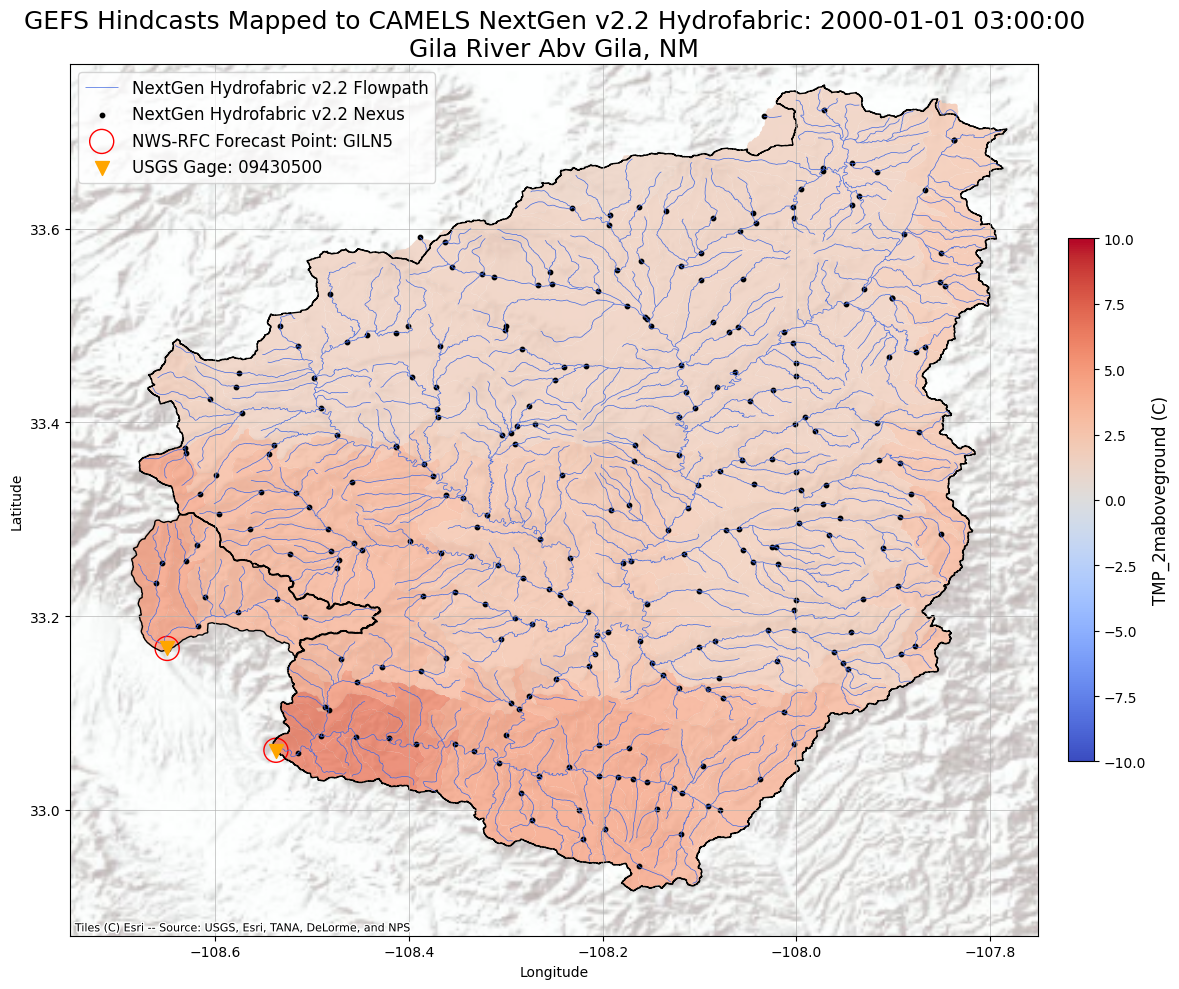

In [3]:
west, south, east, north = (
    -108.75,  # Minimum longitude (west)
    32.87,    # Minimum latitude (south)
    -107.75,  # Maximum longitude (east)
    33.77     # Maximum latitude (north)
)

# Plot the data with basemap
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the GeoDataFrame
divides_forcings.plot(column='TMP_2maboveground', cmap='coolwarm', legend=True, ax=ax, legend_kwds={'shrink': 0.6,'aspect': 20,'pad': 0.02}, alpha=0.8, vmin=-10, vmax=10)
flowpaths.plot(ax=ax, color='royalblue', linewidth=0.5, label='NextGen Hydrofabric v2.2 Flowpath')
nexus.plot(ax=ax, color='black', markersize=10, label='NextGen Hydrofabric v2.2 Nexus')
rfc_fcst_points.plot(ax=ax, color='None', edgecolor='red', marker='o', markersize=300, label='NWS-RFC Forecast Point: GILN5')
                
# Customize the colorbar with a label
cbar = plt.gcf().axes[1]  # Get the colorbar axis (usually the second axis)
cbar.set_ylabel('TMP_2maboveground (C)', fontsize=12)

# Plot the CAMELS outlines
camels.plot(ax=ax, color='none', edgecolor='black', linewidth=1, label='CAMELS Basin Delineation (Revised)')
gauges_gdf.plot(ax=ax, marker='v', color='orange', markersize=100, zorder=11, label='USGS Gage: 09430500')

# Subset to Colorado
ax.set_xlim([west, east])
ax.set_ylim([south, north])
ax.grid(linewidth=0.45)
plt.legend(fontsize=12)

# Add a basemap
# cx.add_basemap(ax, crs=gdf_merged.crs.to_string(), source=cx.providers.Esri.WorldTerrain, zoom=13)  # good for smaller basins
cx.add_basemap(ax, crs=gdf_merged.crs.to_string(), source=cx.providers.Esri.WorldTerrain, zoom=9)

# Customize the plot
plt.title(f'GEFS Hindcasts Mapped to CAMELS NextGen v2.2 Hydrofabric: {airtemp_df.time.iloc[time_idx]}\nGila River Abv Gila, NM', fontsize=18)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Save out
plt.tight_layout()
plt.savefig('gila.gefs_20230101.png', dpi=250)
plt.show()